# Figure S5. UHGV high-confidence filters

In [17]:
### Load packages
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

In [10]:
### Load UHGV metadata
# download UHGV metadata
# !wget https://portal.nersc.gov/cfs/m342/UHGV/metadata/uhgv_metadata.tsv
uhgv_hq_plus = (
    pl.read_csv("../figure_s1/uhgv_metadata.tsv", separator="\t",
        columns=['uhgv_genome', 'checkv_completeness', 'viral_confidence', 'genomad_virus_hallmarks', 'genomad_plasmid_hallmarks', 'genomad_virus_score'], ignore_errors=True)
        .filter(pl.col('checkv_completeness') >= 90)
)

# count uncertain vs confident genomes
print(uhgv_hq_plus.group_by('viral_confidence').len())

shape: (2, 2)
┌──────────────────┬────────┐
│ viral_confidence ┆ len    │
│ ---              ┆ ---    │
│ str              ┆ u32    │
╞══════════════════╪════════╡
│ Uncertain        ┆ 3811   │
│ Confident        ┆ 208604 │
└──────────────────┴────────┘


In [16]:
uhgv_hq_plus.height

212415

(0.0, 95.0)

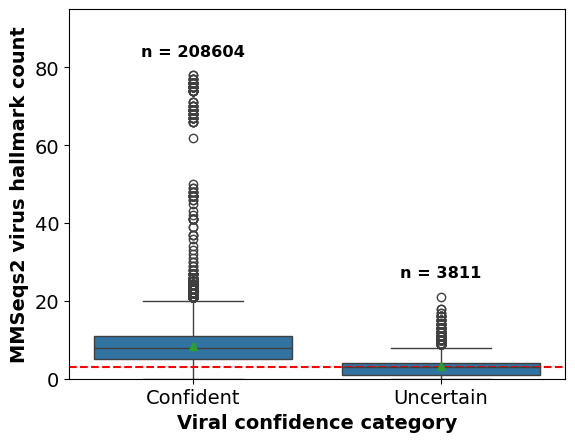

In [21]:
### Plot number of MMSEeqs2 virus hallmarks in UHVDB HQ+ dereplicated genomes
ax = sns.boxplot(data=uhgv_hq_plus, x="viral_confidence", y="genomad_virus_hallmarks", showmeans=True)
plt.ylabel("MMSeqs2 virus hallmark count", fontdict={'fontweight': 'bold'})
plt.xlabel("Viral confidence category", fontdict={'fontweight': 'bold'})
plt.axhline(3, color='r', linestyle='dashed')

maxes = uhgv_hq_plus.group_by(['viral_confidence']).agg([pl.col('genomad_virus_hallmarks').max()]).sort('viral_confidence')['genomad_virus_hallmarks']
nobs = uhgv_hq_plus['viral_confidence'].value_counts().sort('viral_confidence')['count']

# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick],
            maxes[tick] + 5,
            "n = " + str(nobs[tick]),
            horizontalalignment='center',
            size='small',
            color='black',
            weight='semibold')

plt.ylim(0, 95)

(0.0, 55.0)

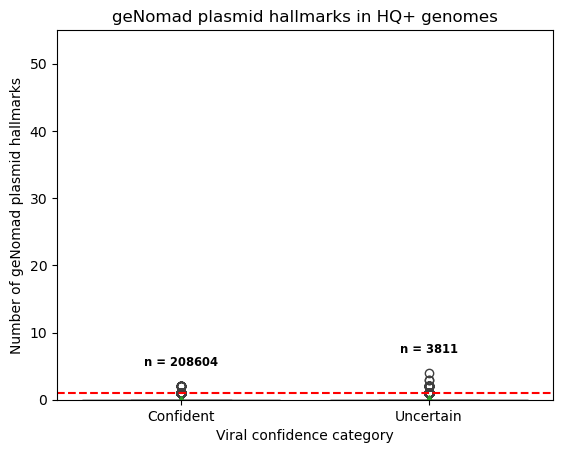

In [13]:
### Plot number of MMSEeqs2 plasmid hallmarks in UHVDB HQ+ dereplicated genomes
ax = sns.boxplot(data=uhgv_hq_plus, x="viral_confidence", y="genomad_plasmid_hallmarks", showmeans=True)
plt.title("geNomad plasmid hallmarks in HQ+ genomes")
plt.ylabel("Number of geNomad plasmid hallmarks")
plt.xlabel("Viral confidence category")
plt.axhline(1, color='r', linestyle='dashed')

maxes = uhgv_hq_plus.group_by(['viral_confidence']).agg([pl.col('genomad_plasmid_hallmarks').max()]).sort('viral_confidence')['genomad_plasmid_hallmarks']
nobs = uhgv_hq_plus['viral_confidence'].value_counts().sort('viral_confidence')['count']

# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick],
            maxes[tick] + 3,
            "n = " + str(nobs[tick]),
            horizontalalignment='center',
            size='small',
            color='black',
            weight='semibold')

plt.ylim(0, 55)

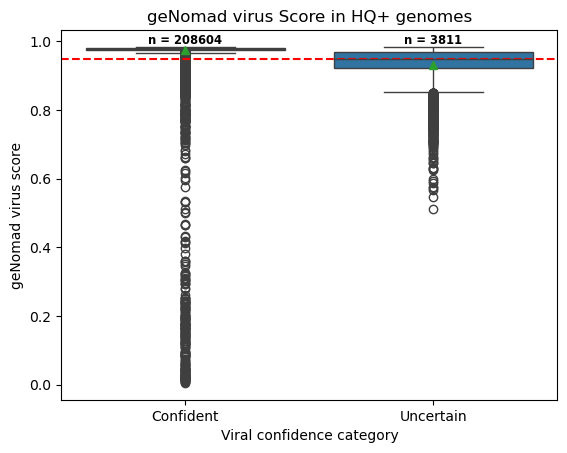

In [14]:
### Plot geNomad virus score in UHVDB HQ+ dereplicated genomes
ax = sns.boxplot(data=uhgv_hq_plus, x="viral_confidence", y="genomad_virus_score", showmeans=True)
plt.title("geNomad virus Score in HQ+ genomes")
plt.ylabel("geNomad virus score")
plt.xlabel("Viral confidence category")
plt.axhline(0.95, color='r', linestyle='dashed')

maxes = uhgv_hq_plus.group_by(['viral_confidence']).agg([pl.col('genomad_virus_score').max()]).sort('viral_confidence')['genomad_virus_score']
nobs = uhgv_hq_plus['viral_confidence'].value_counts().sort('viral_confidence')['count']

# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick],
            maxes[tick] + 0.01,
            "n = " + str(nobs[tick]),
            horizontalalignment='center',
            size='small',
            color='black',
            weight='semibold')

In [15]:
### Extract uncertain genomes for further analysis
# write out file containing uncertain genome ids
uhgv_hq_plus.filter(pl.col('viral_confidence') == 'Uncertain')[['uhgv_genome']].write_csv('uhgv_hq_plus_derep_uncertain.txt', separator='\t')

In [ ]:
# filter fasta file to uncertain genomes
!seqkit grep \
    uhgv_full.fna.gz \
    --pattern-file uhgv_hq_plus_derep_uncertain.txt \
    --out-file uhgv_hq_plus_derep_uncertain.fna

# split uncertain protein fasta into splits with 100 sequences each
!seqkit split2 \
    uhgv_hq_plus_derep_uncertain.fna \
    --by-size 100 \
    --out-dir uhgv_hq_plus_derep_uncertain_split

In [ ]:
### download geNomad markers and extract virus/plasmid hallmarks
!wget https://zenodo.org/records/14886553/files/genomad_hmm_v1.9.tar.gz?download=1 -O genomad_hmm_v1.9.tar.gz
!wget https://zenodo.org/records/14886553/files/genomad_metadata_v1.9.tsv.gz?download=1 -O genomad_metadata_v1.9.tsv.gz

--2025-08-29 11:11:14--  https://zenodo.org/records/14886553/files/genomad_hmm_v1.9.tar.gz?download=1
Resolving zenodo.org (zenodo.org)... 188.185.43.25, 188.185.48.194, 188.185.45.92, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.25|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3508721059 (3.3G) [application/octet-stream]
Saving to: ‘genomad_hmm_v1.9.tar.gz’

genomad_hmm_v1.9.ta 100%[===================>]   3.27G  7.18MB/s    in 9m 21s  

2025-08-29 11:20:36 (5.97 MB/s) - ‘genomad_hmm_v1.9.tar.gz’ saved [3508721059/3508721059]

--2025-08-29 11:20:37--  https://zenodo.org/records/14886553/files/genomad_metadata_v1.9.tsv.gz?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.194, 188.185.43.25, 188.185.45.92, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7110710 (6.8M) [application/octet-stream]
Saving to: ‘genomad_metadata_v1.9.tsv.gz’

genomad_metadata_v1 100%

In [ ]:
### Identify geNomad virus/plasmid hallmarks in hmm files

# identify virus/plasmid hallmarks
genomad_hallmarks = (
    pl.read_csv('genomad_metadata_v1.9.tsv.gz', separator='\t', ignore_errors=True)
        .filter(
            (pl.col('PLASMID_HALLMARK') == 1) | 
            (pl.col('VIRUS_HALLMARK') == 1)
        )[['MARKER']]
        .with_columns([
            ("genomad_hmm_v1.9/" + pl.col('MARKER') + ".hmm").alias('hmm_path')
        ])[['hmm_path']]
        .write_csv('genomad_hallmarks_hmms.txt', include_header=False)
)

In [ ]:
%%bash
## Extract geNomad virus/plasmid hallmarks from hmm files
# gunzip tar file
gunzip genomad_hmm_v1.9.tar.gz

# change to dir to store hmms
tar -xvf genomad_hmm_v1.9.tar --files-from genomad_hallmarks_hmms.txt

combine all hmms into one file
cat genomad_hmm_v1.9/*.hmm > genomad_1_9_hallmarks.hmm

In [ ]:
%%bash
## run hmmsearch against geNomad hallmarks
sbatch hallmark_hmmsearch.sh

In [22]:
### Count number of virus/plasmid hallmarks per genome from hmm results
import polars as pl
import glob

# count hmm hallmark hits per genome
genomad_virus_hallmarks = set(
    pl.read_csv('genomad_metadata_v1.9.tsv.gz', separator='\t', ignore_errors=True)
    .filter(
        (pl.col('VIRUS_HALLMARK') == 1)
    )['MARKER']
)

genomad_plasmid_hallmarks = set(
    pl.read_csv('genomad_metadata_v1.9.tsv.gz', separator='\t', ignore_errors=True)
    .filter(
        (pl.col('PLASMID_HALLMARK') == 1)
    )['MARKER']
)

results = []
for file in glob.glob('uhgv_hq_plus_uncertain_hmm_results/*.tbl'):
    with open(file, 'r') as tbl:
        for line in tbl:
            if '#' in line[0]:
                continue
            strip_split = line.strip().split()
            protein = strip_split[0]
            genome = protein.rsplit('_', 1)[0]
            target = strip_split[2]
            results.append({'genome': genome, 'protein': protein, 'hallmark': target, 'evalue': float(strip_split[4])})
    tbl.close()

(0.0, 75.0)

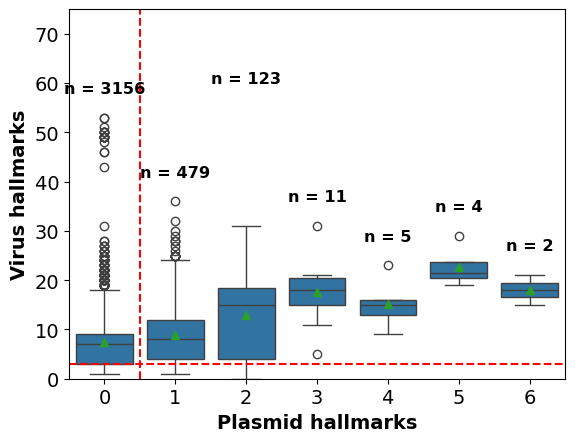

In [26]:
### summarize hallmarks per uncertain genome
uncertain_hmm_hallmarks = (
    pl.DataFrame(results)
        .with_columns([
            pl.when(pl.col('hallmark').is_in(genomad_virus_hallmarks)).then(1).otherwise(0).alias('virus_hallmarks'),
            pl.when(pl.col('hallmark').is_in(genomad_plasmid_hallmarks)).then(1).otherwise(0).alias('plasmid_hallmarks'),
        ])
        .sort('evalue', descending=False)
        .group_by('protein')
        .first()
        .group_by(['genome'])
        .agg([pl.col('virus_hallmarks').sum().alias('virus_hallmarks'), pl.col('plasmid_hallmarks').sum().alias('plasmid_hallmarks')])
        .join(uhgv_hq_plus, left_on='genome', right_on='uhgv_genome')
)

ax = sns.boxplot(data=uncertain_hmm_hallmarks, x="plasmid_hallmarks", y='virus_hallmarks', showmeans=True)
plt.ylabel("Virus hallmarks", fontdict={'fontweight': 'bold'})
plt.xlabel("Plasmid hallmarks", fontdict={'fontweight': 'bold'})
plt.axhline(3, color='r', linestyle='dashed')
plt.axvline(0.5, color='r', linestyle='dashed')

maxes = uncertain_hmm_hallmarks.group_by(['plasmid_hallmarks']).agg([pl.col('virus_hallmarks').max()]).sort('plasmid_hallmarks')['virus_hallmarks']
nobs = uncertain_hmm_hallmarks['plasmid_hallmarks'].value_counts().sort('plasmid_hallmarks')['count']

# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    if pos[tick] == 2:
        maxes[tick] = 55
    ax.text(pos[tick],
            maxes[tick] + 5,
            "n = " + str(nobs[tick]),
            horizontalalignment='center',
            size='small',
            color='black',
            weight='semibold')
plt.ylim(0, 75)

In [25]:
### write out genomes with >= 3 virus hallmarks and 0 plasmid hallmarks (would add 1 point to score)
uncertain2confident = (
    uncertain_hmm_hallmarks
        .filter(
            (pl.col('virus_hallmarks') >= 3) &
            (pl.col('plasmid_hallmarks') == 0)
        )
)

print("Number of sequences that would move from Uncertain to Confident:", uncertain2confident.shape[0])

uncertain2confident[['genome']].write_csv('uhvdb_hq_derep_uncertain2confident.txt', include_header=False)

Number of sequences that would move from Uncertain to Confident: 2501


In [27]:
2501+208604

211105